In [1]:
library(Seurat)
library(dplyr)
library(tibble)
library(patchwork)
library(viridis)
library(ggplot2)
library(RColorBrewer)
library(edgeR)
library(dplyr)
library(readxl)
library(ggplot2)
library(reshape2)
library(data.table)
library(openxlsx)

Attaching SeuratObject

‘SeuratObject’ was built with package ‘Matrix’ 1.6.3 but the current
version is 1.6.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite

Loading required package: limma



In [4]:
setwd ('/lustre1/project/stg_00041/Amitesh')

## Here we are trying to plot number of cells in each conditions (NAIVE, TSC AND EXMCS) which has foci nearest neighbour distance beyond a certin threshold

In [8]:
SIM_data <- read.xlsx("/lustre1/project/stg_00041/Amitesh/3D_SIM/Pooled_data.xlsx", sheet = 1)
head(SIM_data)

,Original.Image.Name,NewCellID,ID,NearestNeighborDistance_1,NearestNeighborDistance_2,NearestNeighborDistance_3,NearestNeighborDistance_4,NearestNeighborDistance_5,CellID,Number.of.foci/nucleus,Foci.Ellipsoid.Axis.Length.C,Foci.Volume,Cell.types
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001293,0.4809652,0.5119364,0.6359268,0.7742367,0.8808540,0,28,2.272871,18.97189,H9 ESC EXMCs
2,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001294,0.3892813,0.5266059,0.6701234,0.7065848,0.7552520,0,28,2.272871,18.97189,H9 ESC EXMCs
3,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001295,0.4461538,0.4491417,0.4500254,0.5119364,0.7316065,0,28,2.272871,18.97189,H9 ESC EXMCs
4,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001296,0.4177421,0.4337813,0.5905469,0.6765182,0.6931436,0,28,2.272871,18.97189,H9 ESC EXMCs
5,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001297,0.2826340,0.4500254,0.4809652,0.5483181,0.5745189,0,28,2.272871,18.97189,H9 ESC EXMCs
6,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001298,0.2826340,0.2933397,0.4874961,0.5343015,0.6261481,0,28,2.272871,18.97189,H9 ESC EXMCs


In [9]:
SIM_data <- SIM_data %>% rename(image="Original.Image.Name", cell_type="Cell.types")
head(SIM_data)

,image,NewCellID,ID,NearestNeighborDistance_1,NearestNeighborDistance_2,NearestNeighborDistance_3,NearestNeighborDistance_4,NearestNeighborDistance_5,CellID,Number.of.foci/nucleus,Foci.Ellipsoid.Axis.Length.C,Foci.Volume,cell_type
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001293,0.4809652,0.5119364,0.6359268,0.7742367,0.8808540,0,28,2.272871,18.97189,H9 ESC EXMCs
2,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001294,0.3892813,0.5266059,0.6701234,0.7065848,0.7552520,0,28,2.272871,18.97189,H9 ESC EXMCs
3,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001295,0.4461538,0.4491417,0.4500254,0.5119364,0.7316065,0,28,2.272871,18.97189,H9 ESC EXMCs
4,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001296,0.4177421,0.4337813,0.5905469,0.6765182,0.6931436,0,28,2.272871,18.97189,H9 ESC EXMCs
5,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001297,0.2826340,0.4500254,0.4809652,0.5483181,0.5745189,0,28,2.272871,18.97189,H9 ESC EXMCs
6,H9 EXMC XIST 594 OLD IMAGE 10_SIM_[ims1_2024-12-10T16-40-31.694],66,200001298,0.2826340,0.2933397,0.4874961,0.5343015,0.6261481,0,28,2.272871,18.97189,H9 ESC EXMCs


Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()` always returns an ungrouped data frame and adjust accordingly.”
`summarise()` has grouped output by 'image', 'CellID', 'cell_type'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'image'. You can override using the `.groups` argument.
Joining with `by = join_by(cell_type)`


cell_type,num_cells_total,total_cells
<chr>,<int>,<int>
H9 ESC EXMCs,28,48
H9 ESC TSCs,18,57
H9 ESCs Naive,27,33
Sigma iPSCs Naive,10,12


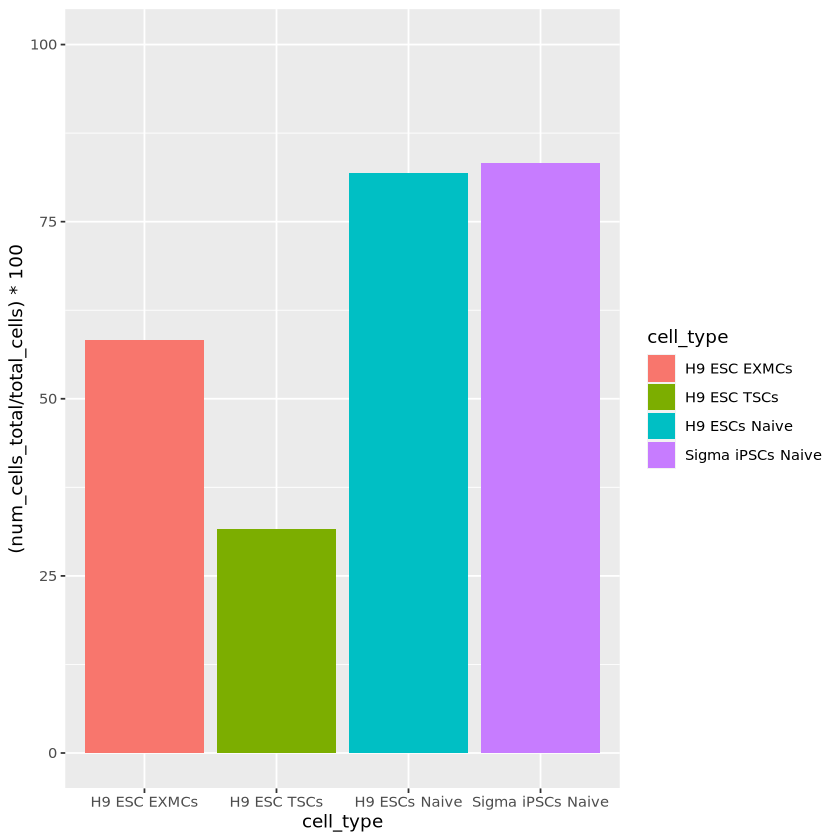

In [11]:
cells_per_image_per_celltype <- SIM_data %>%
    group_by(image, CellID, cell_type) %>%
    summarize(foci_out = case_when(NearestNeighborDistance_5 > 4 ~ 1,
                                   TRUE ~ 0)) %>%
    unique() %>%
    filter(foci_out == 1) %>%
    ungroup() %>%
    group_by(image, cell_type) %>%
    summarize(num_cells = length(foci_out))

total_cells_per_celltype <- SIM_data %>%
    select(image, CellID, cell_type) %>%
    unique() %>%
    group_by(cell_type) %>%
    summarize(total_cells=length(CellID))

cells_per_image_per_celltype <- cells_per_image_per_celltype %>% group_by(cell_type) %>% summarize(num_cells_total = sum(num_cells))

cells_per_image_per_celltype <- left_join(cells_per_image_per_celltype, total_cells_per_celltype)

head(cells_per_image_per_celltype)

p<- ggplot(cells_per_image_per_celltype, aes(x=cell_type, y=(num_cells_total/total_cells) * 100, fill=cell_type)) + ylim(0, 100) +
    geom_bar(stat="identity")
p

## From here onwards trying to make a statistics to see if the plot is significant or not

In [9]:
test_data_h9naive_exmc <- c(cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESCs Naive"),]$num_cells_total,
               cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESCs Naive"),]$total_cells - cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESCs Naive"),]$num_cells_total,
               cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC EXMCs"),]$num_cells_total,
               cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC EXMCs"),]$total_cells - cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC EXMCs"),]$num_cells_total)
test_data_h9naive_exmc

[1] 26  7 20 28

In [10]:
test_data_h9naive_tsc <- c(cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESCs Naive"),]$num_cells_total,
               cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESCs Naive"),]$total_cells - cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESCs Naive"),]$num_cells_total,
               cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC TSCs"),]$num_cells_total,
               cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC TSCs"),]$total_cells - cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC TSCs"),]$num_cells_total)
test_data_h9naive_tsc

[1] 26  7 15 42

In [11]:
test_data_tsc_exmc <- c(cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC TSCs"),]$num_cells_total,
               cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC TSCs"),]$total_cells - cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC TSCs"),]$num_cells_total,
               cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC EXMCs"),]$num_cells_total,
               cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC EXMCs"),]$total_cells - cells_per_image_per_celltype[which(cells_per_image_per_celltype$cell_type == "H9 ESC EXMCs"),]$num_cells_total)
test_data_tsc_exmc

[1] 15 42 20 28

In [12]:
enrichment <- function(data){
    out <- list()
    df <- as.table(rbind(c(data[[1]], data[[2]]), c(data[[3]], data[[4]])))
    dimnames(df) <- list(genes = c("naive", "not_naive"), test = c("Yes", "No"))
    out[[1]] <- fisher.test(df)
    out[[2]] <- chisq.test(df)
    out[[3]] <- as.data.table(df) %>% 
        dcast(genes~test) %>% 
        mutate(total=Yes+No, yes_perc=Yes/(Yes+No), no_perc=No/(Yes+No)) %>%
        select(genes, yes_perc, no_perc) %>%
        melt(id.vars = "genes", ) %>%
        select(-variable) %>%
       mutate(genes_factor=factor(.$genes, levels=c("X-linked genes", "Upregulated genes")))
    return(out)
}

enrichment_barplot <- function(df, title, lim){
    out <- ggplot(df, aes(x=genes_factor, 
                          fill=genes_factor,
                          y=value*100)) +
        geom_bar(stat="identity", color="black", width=1) +
        facet_wrap(~genes_factor, strip.position="bottom", scales="free_x") +
        scale_fill_manual(values=c("#77AADB", "#ee8866")) +
        ggtitle(title) +
        ylab(NULL) +
        xlab(NULL) +
        coord_cartesian(clip="off") +
        scale_x_discrete(labels=c("n=255", "n=72")) +
        scale_y_continuous(labels = function(x){paste0(x, "%")}, expand=c(0,0), limits = c(0, lim)) +
        theme(panel.grid=element_blank(),
              panel.background=element_blank(),
              axis.title.y=element_text(color="black", size=7),
              axis.text.y=element_text(color="black", size=7),
              axis.text.x=element_text(color="black", size=7, margin=margin(t=0, b=0)),
              legend.title=element_text(size=7, hjust=0.5),
              axis.ticks=element_line(color="black"),
              axis.ticks.x=element_blank(),
              axis.line.x=element_line(color="black"),
              axis.line.y=element_line(color="black"),
              legend.text=element_text(size=7),
              legend.position="none",
              plot.title=element_text(size=7, hjust=0.5),
              strip.background = element_blank(),
              strip.placement = "outside",
              strip.text.x = element_text(color="black", angle=90, size=7, hjust=1, vjust=0.5, margin=margin(t=0)),
              panel.spacing = unit(0, "lines"))    
    return(out)
}           

In [13]:
enrichment(test_data_h9naive_exmc)
enrichment(test_data_h9naive_tsc)
enrichment(test_data_tsc_exmc)

Using 'N' as value column. Use 'value.var' to override



[[1]]

	Fisher's Exact Test for Count Data

data:  df
p-value = 0.001284
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  1.724772 16.767374
sample estimates:
odds ratio 
  5.089015 


[[2]]

	Pearson's Chi-squared test with Yates' continuity correction

data:  df
X-squared = 9.5208, df = 1, p-value = 0.002032


[[3]]
       genes     value genes_factor
1:     naive 0.7878788         <NA>
2: not_naive 0.4166667         <NA>
3:     naive 0.2121212         <NA>
4: not_naive 0.5833333         <NA>


Using 'N' as value column. Use 'value.var' to override



[[1]]

	Fisher's Exact Test for Count Data

data:  df
p-value = 2.144e-06
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  3.406666 33.659986
sample estimates:
odds ratio 
  10.07536 


[[2]]

	Pearson's Chi-squared test with Yates' continuity correction

data:  df
X-squared = 21.134, df = 1, p-value = 4.283e-06


[[3]]
       genes     value genes_factor
1:     naive 0.7878788         <NA>
2: not_naive 0.2631579         <NA>
3:     naive 0.2121212         <NA>
4: not_naive 0.7368421         <NA>


Using 'N' as value column. Use 'value.var' to override



[[1]]

	Fisher's Exact Test for Count Data

data:  df
p-value = 0.1029
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.2018175 1.2305809
sample estimates:
odds ratio 
 0.5033845 


[[2]]

	Pearson's Chi-squared test with Yates' continuity correction

data:  df
X-squared = 2.1155, df = 1, p-value = 0.1458


[[3]]
       genes     value genes_factor
1:     naive 0.2631579         <NA>
2: not_naive 0.4166667         <NA>
3:     naive 0.7368421         <NA>
4: not_naive 0.5833333         <NA>


## If we want to show both XIST spreaded and not spreaded cloud

In [39]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.4
✔ lubridate 1.9.3     ✔ stringr   1.5.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ data.table::between() masks dplyr::between()
✖ dplyr::filter()       masks stats::filter()
✖ data.table::first()   masks dplyr::first()
✖ lubridate::hour()     masks data.table::hour()
✖ lubridate::isoweek()  masks data.table::isoweek()
✖ dplyr::lag()          masks stats::lag()
✖ data.table::last()    masks dplyr::last()
✖ lubridate::mday()     masks data.table::mday()
✖ lubridate::minute()   masks data.table::minute()
✖ lubridate::month()    masks data.table::month()
✖ lubridate::quarter()  masks data.table::quarter()
✖ lubridate::second()   masks data

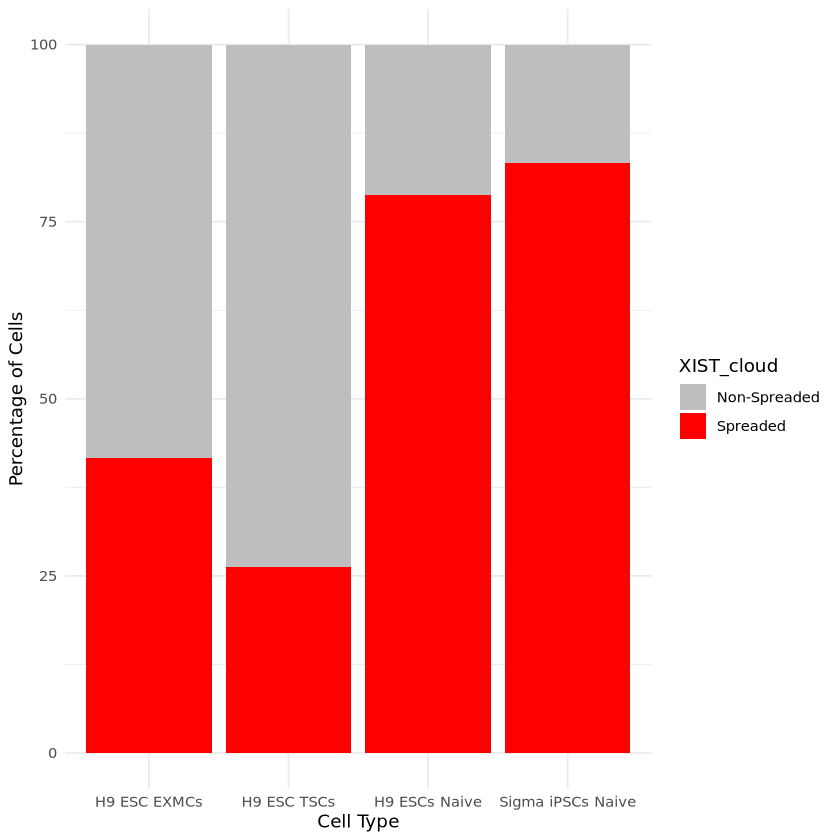

In [70]:
cells_per_image_per_celltype <- cells_per_image_per_celltype %>%
    mutate(non_spreaded = total_cells - num_cells_total) %>%
    pivot_longer(cols = c(num_cells_total, non_spreaded), names_to = "XIST_cloud", values_to = "cell_count") %>%
    mutate(XIST_cloud = ifelse(XIST_cloud == "num_cells_total", "Spreaded", "Non-Spreaded"))

p1<- ggplot(cells_per_image_per_celltype, aes(x=cell_type, y=(cell_count/total_cells) * 100, fill=XIST_cloud)) +
    geom_bar(stat="identity") +
    ylim(0, 100) +
    ylab("Percentage of Cells") +
    xlab("Cell Type") +
    scale_fill_manual(values=c("Spreaded"="red", "Non-Spreaded"="gray")) +
    theme_minimal()
p1

In [107]:

pdf("/lustre1/project/stg_00041/Amitesh/3D_SIM/output/NND_5_THRESHOLD_5_withandwithoutXIST_spreaded_nuclei.pdf", width = 10, height = 10)
plot(p1)
dev.off()

png 
  2

## Can we plot the number of foci per cells

In [20]:
SIM_data <- SIM_data %>% rename(number_of_foci_per_cell="Number.of.foci/nucleus")

In [21]:
unique_foci_data <- SIM_data %>%
  group_by(cell_type) %>%
  summarise(unique_foci = unique(`number_of_foci_per_cell`)) %>%
  ungroup()
unique_foci_data

Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()` always returns an ungrouped data frame and adjust accordingly.”
`summarise()` has grouped output by 'cell_type'. You can override using the `.groups` argument.


cell_type,unique_foci
<chr>,<dbl>
H9 ESC EXMCs,28
H9 ESC EXMCs,26
H9 ESC EXMCs,16
H9 ESC EXMCs,35
H9 ESC EXMCs,21
H9 ESC EXMCs,18
H9 ESC EXMCs,32
H9 ESC EXMCs,33
H9 ESC EXMCs,13


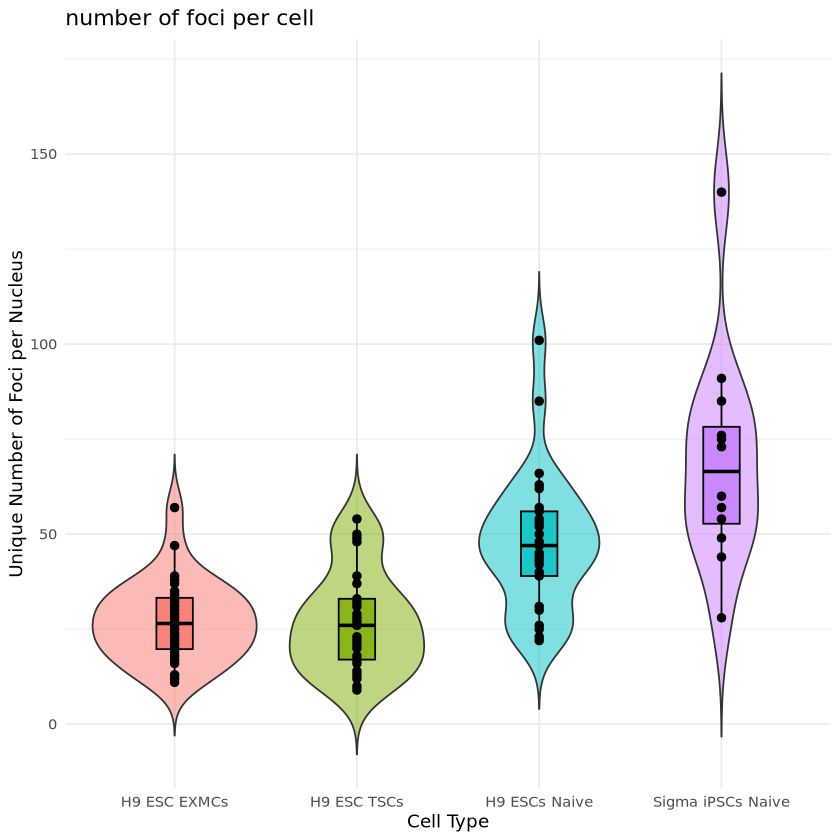

In [22]:
# Create the box plot and violin plot overlay
p3<- ggplot(unique_foci_data, aes(x = cell_type, y = unique_foci, fill = cell_type)) +
  geom_violin(trim = FALSE, alpha = 0.5) +  # Violin plot with some transparency
  geom_boxplot(width = 0.2, color = "black", alpha = 0.8) +  
geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) + # Box plot with smaller width
  theme_minimal() +
  labs(title = "number of foci per cell",
       x = "Cell Type",
       y = "Unique Number of Foci per Nucleus") +
  theme(legend.position = "none")
p3

In [106]:

pdf("/lustre1/project/stg_00041/Amitesh/3D_SIM/output/number_of_foci_per_celltype.pdf", width = 10, height = 10)
plot(p3)
dev.off()

png 
  2